# 27 — `voronoi`

`Map.voronoi` turns scattered **point** measurements into a tessellation: one cell per point, covering every
place that point is the nearest one to. It answers the question a scatter plot cannot — *which gauge speaks for
this patch of ground?* — so it is the natural first map for a sparse monitoring network.

By the end of this notebook you will be able to build a Voronoi map from a point `FeatureCollection`, colour its
cells by an attribute, and trim them to a real boundary with `clip=`.

API: [`Map.voronoi`](../../reference/static_map.md).

**Setup** — inline figures, and the one path to the bundled example data.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")


## The data

34 discharge gauges on the Rhine and its tributaries, stored in **EPSG:3035** (ETRS89 / LAEA Europe). A metric,
equal-area CRS matters here: Voronoi cells are built from straight-line distances, so computing them in degrees
would stretch every cell east–west.

In [2]:
gauges = FeatureCollection.read_file(str(DATA / "rhine_gauges.geojson"))
print(f"{len(gauges)} gauges, EPSG:{gauges.crs.to_epsg()}")
gauges[["name", "river", "datum(m)"]].head()

34 gauges, EPSG:3035


C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\dev\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


,name,river,datum(m)
0,Plochingen,NECKAR,252.36
1,Lauffen,NECKAR,159.37
2,Rockenau,NECKAR,119.71
3,Maxau,RHEIN,97.72
4,Speyer,RHEIN,88.51


`datum(m)` is each gauge's reference elevation in metres — 0 m near the North-Sea outlet up to ~252 m in the
southern headwaters. That is the attribute we will colour by.

## Quickstart — the bare tessellation

The minimal call takes just the points. Every cell is drawn in one colour, so the map shows *geometry only*: how
much ground each gauge is responsible for.

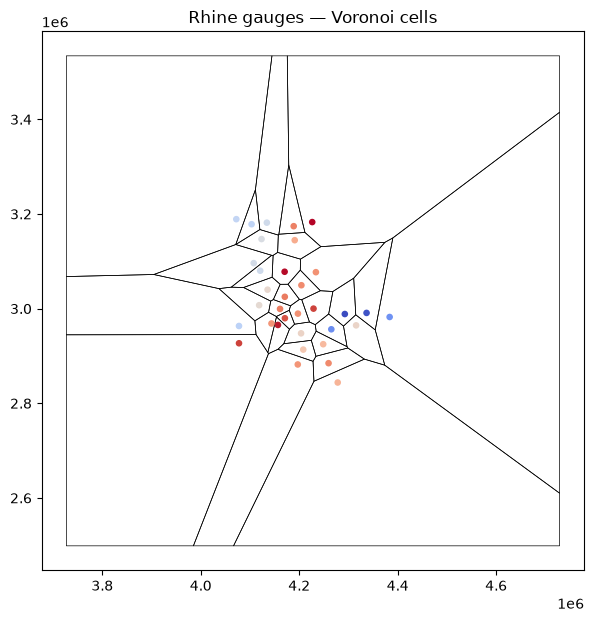

In [3]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.voronoi(gauges)
m.points(gauges, size=14)
m.set_title("Rhine gauges — Voronoi cells")
m.fig;

Read the cell sizes, not the colours: the small cells along the middle Rhine are where gauges sit close together,
and the large cells on the rim are headwater gauges with no neighbour for tens of kilometres. A large cell is a
warning — one gauge is standing in for a lot of catchment.

## Colouring by a value

Passing `column=` colours each cell by its own point's attribute, which is what makes a Voronoi map a *nearest-
neighbour interpolation* you can read: every location takes the value of the gauge nearest to it.

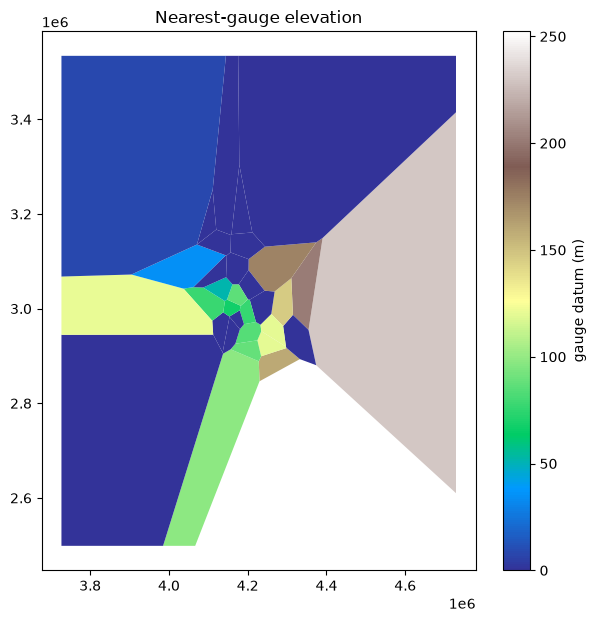

In [4]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.voronoi(gauges, column="datum(m)", cmap="terrain")
m.colorbar(label="gauge datum (m)")
m.set_title("Nearest-gauge elevation")
m.fig;

The result is a coarse elevation surface built from 34 numbers — low along the Rhine corridor running
north-west, high in the southern and eastern headwaters. The hard edges are honest: the method claims no
knowledge between gauges, unlike a smooth interpolation that would invent it.

## Trimming to a boundary with `clip=`

Unclipped, the outermost cells run off to the edge of the figure — they are unbounded in principle. `clip=`
intersects every cell with a polygon layer, so the map stops where the study area does.

| argument | meaning | typical value |
|---|---|---|
| `features` | the point collection to tessellate | a point `FeatureCollection` |
| `column` | attribute to colour cells by | `None` (one colour) or a column name |
| `clip` | polygons to intersect the cells with | a polygon `FeatureCollection` |

In [5]:
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
germany = states.to_crs(gauges.crs)   # match the gauges' metric CRS before clipping
print(f"{len(germany)} states, reprojected to EPSG:{germany.crs.to_epsg()}")

16 states, reprojected to EPSG:3035


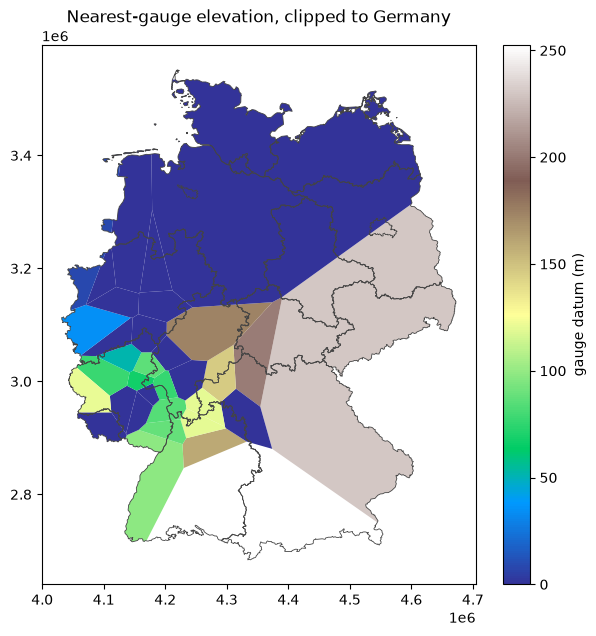

In [6]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.voronoi(gauges, column="datum(m)", cmap="terrain", clip=germany)
m.polygons(germany, edgecolor="#444444", linewidth=0.6)
m.colorbar(label="gauge datum (m)")
m.set_title("Nearest-gauge elevation, clipped to Germany")
m.fig;

Now the tessellation reads as a thematic map of a real place. Note the two consequences of clipping: the ragged
outer cells are gone, and the gaps — northern and eastern Germany — are where this network simply has no gauges,
which the unclipped version hid by stretching cells across them.

## Takeaway

- `voronoi(points)` shows **coverage**: how much ground each sample is responsible for.
- `voronoi(points, column=...)` shows **nearest-neighbour values** — a surface with no invented smoothness.
- `clip=` bounds the cells to a real study area, and makes the network's gaps visible instead of hiding them.
- Build it in a metric CRS; distances in degrees distort every cell.

Next: [`28_quadtree`](28_quadtree.ipynb) aggregates points into adaptive cells instead of one cell per point.